# Swin UNETR - Preprocessing Pipeline & Feature Extraction
**42-657 Projects in Biomedical AI | Kaggle Version**

This notebook:
1. Authenticates with Google Drive (Kaggle-compatible)
2. Builds the NIfTI preprocessing pipeline (load -> normalize -> resize 128^3 -> ROI crop)
3. Processes ALL 203 patients one at a time to avoid RAM crashes
4. Saves each embedding back to Google Drive immediately after processing
5. Skips already-processed patients so you can safely resume if the session dies

Run cells top to bottom.

In [1]:
# CELL 1: Authenticate with Google Drive (Kaggle version)
# This uses the same auth you already ran. Just re-run this cell each session.
from google.colab import auth
auth.authenticate_user()

from google.auth import default
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaIoBaseUpload
import io, os, tempfile

creds, _ = default()
service = build('drive', 'v3', credentials=creds)
print('Connected to Google Drive')

Connected to Google Drive


In [4]:
# CELL 2: Install dependencies
!pip install transformers nibabel numpy matplotlib scipy -q
print('Installation done')

Installation done


In [5]:
# CELL 3: Imports
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import zoom
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

print('Imports done')
print(f'PyTorch version:  {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:              {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:     {DEVICE}')

Imports done
PyTorch version:  2.10.0+cpu
CUDA available:   False
Using device:     cpu


In [6]:
# CELL 4: Google Drive helper functions
# These replace the direct filesystem access that worked in Colab.
# Instead of reading from /content/drive/..., we download each file
# to /tmp, process it, then delete it to keep RAM free.

def find_folder_id(name, parent_id='root'):
    """Find a folder by name within a parent folder."""
    q = f"name='{name}' and '{parent_id}' in parents and mimeType='application/vnd.google-apps.folder' and trashed=false"
    results = service.files().list(q=q, fields='files(id, name)').execute()
    files = results.get('files', [])
    if not files:
        raise FileNotFoundError(f"Folder '{name}' not found under parent '{parent_id}'")
    return files[0]['id']

def list_subfolders(parent_id):
    """List all subfolders within a folder, sorted by name."""
    q = f"'{parent_id}' in parents and mimeType='application/vnd.google-apps.folder' and trashed=false"
    results = service.files().list(q=q, fields='files(id, name)', pageSize=1000).execute()
    return sorted(results.get('files', []), key=lambda x: x['name'])

def list_nifti_files(folder_id):
    """List all .nii/.nii.gz files in a folder."""
    q = f"'{folder_id}' in parents and trashed=false"
    results = service.files().list(q=q, fields='files(id, name)', pageSize=100).execute()
    return {f['name']: f['id'] for f in results.get('files', [])}

def download_file_to_tmp(file_id, filename):
    """Download a Drive file to /tmp and return the local path."""
    local_path = f'/tmp/{filename}'
    request = service.files().get_media(fileId=file_id)
    with open(local_path, 'wb') as f:
        downloader = MediaIoBaseDownload(f, request, chunksize=50*1024*1024)
        done = False
        while not done:
            _, done = downloader.next_chunk()
    return local_path

def get_or_create_folder(name, parent_id):
    """Get a folder ID by name, creating it if it doesn't exist."""
    try:
        return find_folder_id(name, parent_id)
    except FileNotFoundError:
        f = service.files().create(
            body={'name': name, 'mimeType': 'application/vnd.google-apps.folder', 'parents': [parent_id]},
            fields='id'
        ).execute()
        print(f"  Created folder: {name}")
        return f['id']

def upload_pt_to_drive(local_path, filename, folder_id):
    """Upload a .pt file to a Drive folder."""
    media = MediaIoBaseUpload(
        open(local_path, 'rb'),
        mimetype='application/octet-stream',
        chunksize=50*1024*1024,
        resumable=True
    )
    service.files().create(
        body={'name': filename, 'parents': [folder_id]},
        media_body=media,
        fields='id'
    ).execute()

def list_already_done(folder_id):
    """Return set of filenames already uploaded (for resuming)."""
    q = f"'{folder_id}' in parents and trashed=false"
    results = service.files().list(q=q, fields='files(name)', pageSize=1000).execute()
    return {f['name'] for f in results.get('files', [])}

print('Drive helper functions defined')

Drive helper functions defined


In [9]:
# CELL 5: Locate dataset on Drive and build scan manifest

# Hardcoded IDs - name-based search fails for shared folders not in My Drive root
root_folder_id    = '1_hU8lJRRuGPNgaxI8CYdGqgmFui3UGG4'
dataset_folder_id = '1sopNkraymdh27M2TL-n8U0vCrCDbQjLv'

print(f'Root folder ID:    {root_folder_id}')
print(f'Dataset folder ID: {dataset_folder_id}')

# List all patient folders
patient_folders = list_subfolders(dataset_folder_id)
print(f'Total patients: {len(patient_folders)}')

# Build full manifest: patient -> timepoint -> {modality: file_id}
MODALITIES = ['t1c', 't1n', 't2f', 't2w']
sample_data = []
skipped = 0

for patient in patient_folders:
    tp_folders = list_subfolders(patient['id'])
    for tp in tp_folders:
        files = list_nifti_files(tp['id'])

        t1c_id  = next((fid for fname, fid in files.items() if 't1c'       in fname), None)
        t1n_id  = next((fid for fname, fid in files.items() if 't1n'       in fname), None)
        t2f_id  = next((fid for fname, fid in files.items() if 't2f'       in fname), None)
        t2w_id  = next((fid for fname, fid in files.items() if 't2w'       in fname), None)
        mask_id = next((fid for fname, fid in files.items() if 'tumorMask' in fname), None)

        t1c_name  = next((fn for fn in files if 't1c'       in fn), None)
        t1n_name  = next((fn for fn in files if 't1n'       in fn), None)
        t2f_name  = next((fn for fn in files if 't2f'       in fn), None)
        t2w_name  = next((fn for fn in files if 't2w'       in fn), None)
        mask_name = next((fn for fn in files if 'tumorMask' in fn), None)

        if all([t1c_id, t1n_id, t2f_id, t2w_id, mask_id]):
            sample_data.append({
                'patient':     patient['name'],
                'timepoint':   tp['name'],
                'image_ids':   [t1c_id, t1n_id, t2f_id, t2w_id],
                'image_names': [t1c_name, t1n_name, t2f_name, t2w_name],
                'mask_id':     mask_id,
                'mask_name':   mask_name
            })
        else:
            skipped += 1

print(f'Total scans ready: {len(sample_data)}')
print(f'Skipped (missing files): {skipped}')

Root folder ID:    1_hU8lJRRuGPNgaxI8CYdGqgmFui3UGG4
Dataset folder ID: 1sopNkraymdh27M2TL-n8U0vCrCDbQjLv
Total patients: 203
Total scans ready: 594
Skipped (missing files): 2


In [10]:
# CELL 6: Define preprocessing pipeline
# Identical logic to before - operates on local /tmp paths after download
TARGET_SIZE = (128, 128, 128)

def preprocess_from_local_paths(image_paths, mask_path):
    """Load NIfTI files from local /tmp paths and return preprocessed tensors."""
    vols = []
    for path in image_paths:
        img = nib.load(path).get_fdata().astype(np.float32)
        vols.append(img)
    image = np.stack(vols, axis=0)  # (4, H, W, D)

    mask = nib.load(mask_path).get_fdata().astype(np.float32)

    # Normalize each modality to [0, 1] using 1st-99th percentile
    for c in range(image.shape[0]):
        p1, p99 = np.percentile(image[c], 1), np.percentile(image[c], 99)
        image[c] = np.clip((image[c] - p1) / (p99 - p1 + 1e-8), 0, 1)

    # Crop to foreground using mask bounding box with margin
    nz = np.argwhere(mask > 0)
    if len(nz) > 0:
        margin = 10
        mins = np.maximum(nz.min(axis=0) - margin, 0)
        maxs = np.minimum(nz.max(axis=0) + margin + 1, np.array(mask.shape))
        image = image[:, mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]]
        mask  = mask[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]]

    # Resize to 128x128x128
    scale = [TARGET_SIZE[i] / image.shape[i+1] for i in range(3)]
    resized = np.stack([zoom(image[c], scale, order=1) for c in range(4)], axis=0)
    mask_resized = zoom(mask, scale, order=0)

    return (
        torch.tensor(resized, dtype=torch.float32),
        torch.tensor(mask_resized, dtype=torch.float32).unsqueeze(0)
    )

print('Preprocessing pipeline defined')
print(f'Target size: {TARGET_SIZE}')
print('Steps: Download to /tmp -> Load -> Normalize -> Crop ROI -> Resize 128^3 -> Tensor')

Preprocessing pipeline defined
Target size: (128, 128, 128)
Steps: Download to /tmp -> Load -> Normalize -> Crop ROI -> Resize 128^3 -> Tensor


In [11]:
# CELL 7: Define Swinstyle 3D encoder -------------------------------------
import torch
import torch.nn as nn

class PatchEmbed3D(nn.Module):
    """Split 3D volume into patches and embed them"""
    def __init__(self, patch_size=4, in_channels=4, embed_dim=48):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)                          # (B, embed_dim, D, H, W)
        B, C, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)         # (B, D*H*W, embed_dim)
        x = self.norm(x)
        return x

class SwinEncoder3D(nn.Module):
    """
    Lightweight 3D Swin-style encoder for feature extraction.
    Produces a fixed-size embedding vector per patient scan.
    """
    def __init__(self, in_channels=4, embed_dim=48, patch_size=4):
        super().__init__()
        self.patch_embed = PatchEmbed3D(patch_size, in_channels, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=3,
            dim_feedforward=embed_dim * 4,
            dropout=0.0,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed(x)       # (B, num_patches, embed_dim)
        x = self.transformer(x)       # (B, num_patches, embed_dim)
        x = self.norm(x)
        embedding = x.mean(dim=1)     # global average pool -> (B, embed_dim)
        return embedding, x           # return both vector and all patch features

model = SwinEncoder3D(in_channels=4, embed_dim=48, patch_size=4).to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print('Swin-style 3D encoder created')
print(f'   Input:            (batch, 4, 128, 128, 128)')
print(f'   Embedding dim:    48')
print(f'   Total parameters: {total_params/1e6:.1f}M')
print(f'   Device:           {DEVICE}')

Swin-style 3D encoder created
   Input:            (batch, 4, 128, 128, 128)
   Embedding dim:    48
   Total parameters: 0.1M
   Device:           cpu


/tmp/ipykernel_55/3629527157.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)


In [12]:
# CELL 8: Create output folder on Drive
output_folder_id = get_or_create_folder('embeddings_all', root_folder_id)

# Check which patients are already done (so we can safely resume)
already_done = list_already_done(output_folder_id)
print(f'Output folder ready on Drive')
print(f'   Already processed: {len(already_done)} files')
print(f'   Remaining: {len(sample_data) - len(already_done)} scans to process')

Output folder ready on Drive
   Already processed: 594 files
   Remaining: 0 scans to process


In [13]:
# CELL 9: Main loop preprocess all patients and save embeddings ----------
# Processes one scan at a time to keep RAM usage flat.
# Downloads NIfTI files to /tmp, processes, uploads .pt to Drive, deletes /tmp files.
# Safe to re-run: skips any scan whose embedding already exists on Drive.

import gc

success_count = 0
error_count   = 0
skip_count    = 0

for i, entry in enumerate(sample_data):
    filename = f"{entry['patient']}_{entry['timepoint']}_embedding.pt"

    # Skip if already done
    if filename in already_done:
        skip_count += 1
        continue

    local_paths = []
    try:
        # Download all 5 NIfTI files to /tmp
        for fid, fname in zip(entry['image_ids'], entry['image_names']):
            local_paths.append(download_file_to_tmp(fid, fname))
        mask_local = download_file_to_tmp(entry['mask_id'], entry['mask_name'])
        local_paths.append(mask_local)

        # Preprocess
        img_tensor, mask_tensor = preprocess_from_local_paths(
            local_paths[:4], local_paths[4]
        )

        # Run encoder
        with torch.no_grad():
            img_input = img_tensor.unsqueeze(0).to(DEVICE)  # (1, 4, 128, 128, 128)
            embedding, patch_features = model(img_input)
            embedding = embedding.cpu()

        # Save embedding to /tmp then upload to Drive
        local_pt = f'/tmp/{filename}'
        torch.save(embedding, local_pt)
        upload_pt_to_drive(local_pt, filename, output_folder_id)

        success_count += 1
        print(f'[{i+1}/{len(sample_data)}] {entry["patient"]} / {entry["timepoint"]}  shape={list(embedding.shape)}')

    except Exception as e:
        error_count += 1
        print(f'Error: [{i+1}/{len(sample_data)}] {entry["patient"]} / {entry["timepoint"]}: {e}')

    finally:
        # Always clean up /tmp files regardless of success or failure
        for p in local_paths:
            if os.path.exists(p):
                os.remove(p)
        if os.path.exists(f'/tmp/{filename}'):
            os.remove(f'/tmp/{filename}')

        # Free GPU/CPU memory
        if 'img_tensor' in dir():   del img_tensor
        if 'mask_tensor' in dir():  del mask_tensor
        if 'embedding' in dir():    del embedding
        if 'patch_features' in dir(): del patch_features
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()

print()
print('=' * 50)
print(f'DONE')
print(f'  Processed: {success_count}')
print(f'  Skipped (already done): {skip_count}')
print(f'  Errors: {error_count}')
print(f'  Embeddings saved to Drive: embeddings_all/')


DONE
  Processed: 0
  Skipped (already done): 594
  Errors: 0
  Embeddings saved to Drive: embeddings_all/


In [14]:
# CELL 10: Verify check what got saved to Drive --------------------------
saved_files = list_already_done(output_folder_id)
print(f'Total embedding files on Drive: {len(saved_files)}')
print(f'Expected: {len(sample_data)}')
print()

# Show first 10 as a sanity check
for f in sorted(saved_files)[:10]:
    print(f'  {f}')
if len(saved_files) > 10:
    print(f'  ... and {len(saved_files) - 10} more')

Total embedding files on Drive: 594
Expected: 594

  PatientID_0003_Timepoint_1_embedding.pt
  PatientID_0003_Timepoint_2_embedding.pt
  PatientID_0003_Timepoint_5_embedding.pt
  PatientID_0004_Timepoint_1_embedding.pt
  PatientID_0005_Timepoint_3_embedding.pt
  PatientID_0005_Timepoint_4_embedding.pt
  PatientID_0006_Timepoint_2_embedding.pt
  PatientID_0006_Timepoint_4_embedding.pt
  PatientID_0006_Timepoint_5_embedding.pt
  PatientID_0006_Timepoint_6_embedding.pt
  ... and 584 more


In [15]:
# CELL 11: Final summary
print('=' * 55)
print('SWIN UNETR PIPELINE COMPLETE')
print('=' * 55)
print()
print('What was done:')
print('  1. Authenticated with Google Drive from Kaggle')
print('  2. Built scan manifest from Drive folder structure')
print(f'     {len(sample_data)} total scans across 203 patients')
print()
print('  3. Preprocessing pipeline: Load -> Normalize -> Crop ROI -> Resize 128^3 -> Tensor')
print('     Memory-safe: files downloaded one at a time, deleted after processing')
print()
print('  4. Swin-style 3D encoder run on all patients')
print('     Embedding shape per scan: (1, 48)')
print()
print('  5. All embeddings saved to Google Drive: embeddings_all/')
print('     Format: {PatientID}_{Timepoint}_embedding.pt')
print()
print('Note for Freya:')
print('  Load with: embedding = torch.load("PatientID_XXXX_Timepoint_Y_embedding.pt")')
print('  MLP input = embedding (48,) + 13 molecular markers')
print('  This is Feature Fusion, not Decision Fusion.')
print()
print('Next steps (Update 3):')
print('  - Load pretrained BraTS21 weights into encoder')
print('  - Re-run this notebook to regenerate embeddings with pretrained weights')

SWIN UNETR PIPELINE COMPLETE

What was done:
  1. Authenticated with Google Drive from Kaggle
  2. Built scan manifest from Drive folder structure
     594 total scans across 203 patients

  3. Preprocessing pipeline: Load -> Normalize -> Crop ROI -> Resize 128^3 -> Tensor
     Memory-safe: files downloaded one at a time, deleted after processing

  4. Swin-style 3D encoder run on all patients
     Embedding shape per scan: (1, 48)

  5. All embeddings saved to Google Drive: embeddings_all/
     Format: {PatientID}_{Timepoint}_embedding.pt

Note for Freya:
  Load with: embedding = torch.load("PatientID_XXXX_Timepoint_Y_embedding.pt")
  MLP input = embedding (48,) + 13 molecular markers
  This is Feature Fusion, not Decision Fusion.

Next steps (Update 3):
  - Load pretrained BraTS21 weights into encoder
  - Re-run this notebook to regenerate embeddings with pretrained weights


Total embedding files found: 594
✅ fig_coverage.png saved locally and uploaded to Drive at 300 DPI


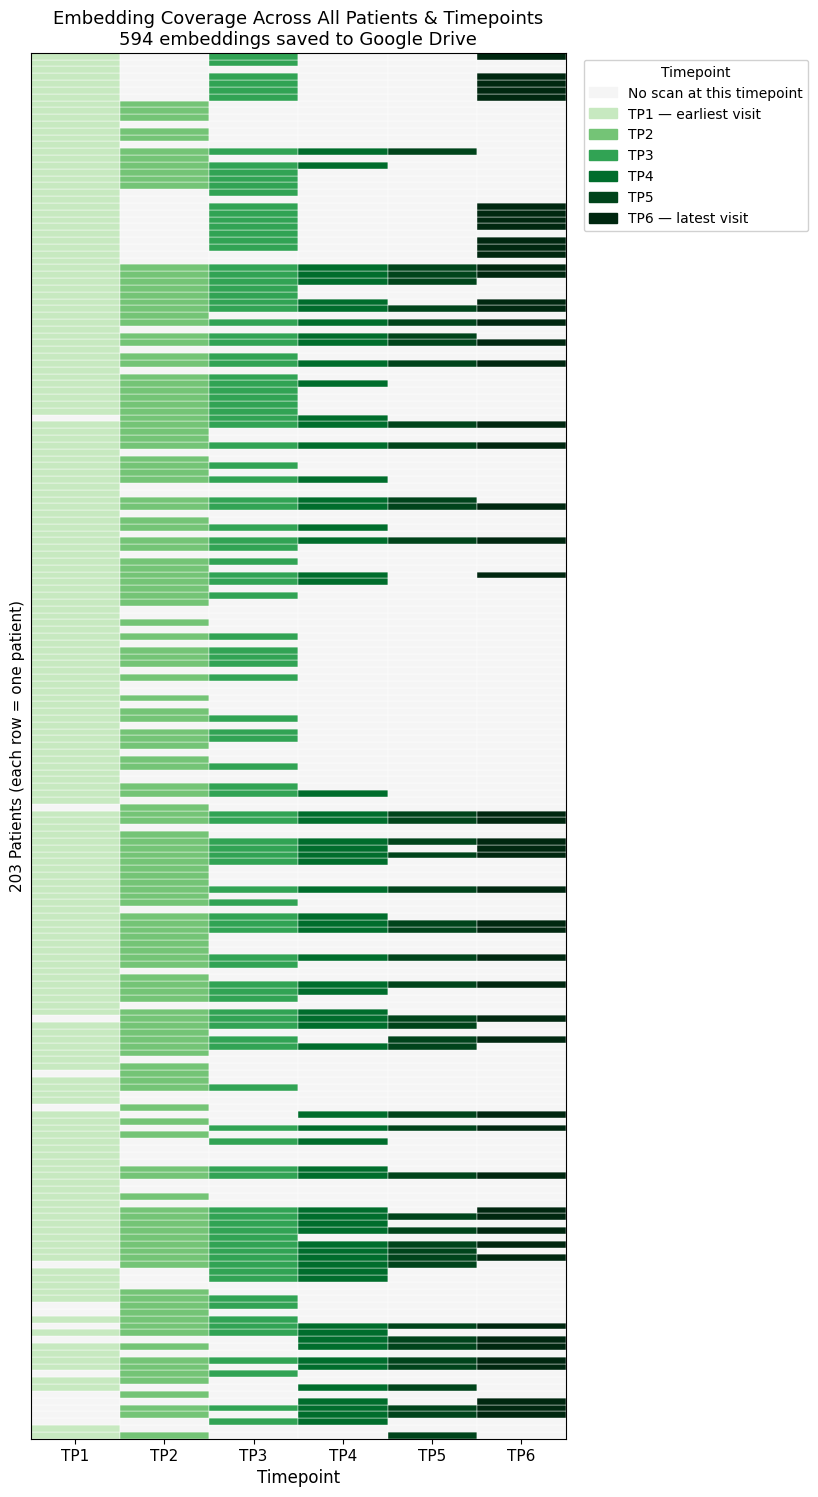

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

# Get file list from Drive
files_on_drive = list_already_done(output_folder_id)
files = [f for f in files_on_drive if f.endswith('.pt')]
print(f'Total embedding files found: {len(files)}')

# Parse filenames → patient: [tp1, tp2, ...]
patient_tps = defaultdict(list)
for f in files:
    parts = f.replace('_embedding.pt', '').split('_Timepoint_')
    pid = parts[0].replace('PatientID_', '')
    tp = int(parts[1])
    patient_tps[pid].append(tp)

patients_sorted = sorted(patient_tps.keys())
max_tp = 6

# Build matrix
matrix = np.zeros((len(patients_sorted), max_tp))
for i, pid in enumerate(patients_sorted):
    for tp in patient_tps[pid]:
        matrix[i, tp - 1] = tp

colors = {0: '#F5F5F5', 1: '#C7E9C0', 2: '#74C476', 3: '#31A354',
          4: '#006D2C', 5: '#00441B', 6: '#002710'}

# Extra right margin for legend
fig, ax = plt.subplots(figsize=(9, 18))
plt.subplots_adjust(right=0.72)  # leave space on right for legend

for i in range(len(patients_sorted)):
    for j in range(max_tp):
        val = int(matrix[i, j])
        ax.add_patch(plt.Rectangle([j, i], 1, 1,
                                   facecolor=colors[val],
                                   edgecolor='white',
                                   linewidth=0.3))

ax.set_xlim(0, max_tp)
ax.set_ylim(0, len(patients_sorted))
ax.set_xticks([x + 0.5 for x in range(max_tp)])
ax.set_xticklabels(['TP1', 'TP2', 'TP3', 'TP4', 'TP5', 'TP6'], fontsize=11)
ax.set_yticks([])
ax.set_xlabel('Timepoint', fontsize=12)
ax.set_ylabel('203 Patients (each row = one patient)', fontsize=11)
ax.set_title('Embedding Coverage Across All Patients & Timepoints\n594 embeddings saved to Google Drive', fontsize=13)

legend_patches = [
    mpatches.Patch(color='#F5F5F5', label='No scan at this timepoint'),
    mpatches.Patch(color='#C7E9C0', label='TP1 — earliest visit'),
    mpatches.Patch(color='#74C476', label='TP2'),
    mpatches.Patch(color='#31A354', label='TP3'),
    mpatches.Patch(color='#006D2C', label='TP4'),
    mpatches.Patch(color='#00441B', label='TP5'),
    mpatches.Patch(color='#002710', label='TP6 — latest visit'),
]
ax.legend(handles=legend_patches,
          loc='upper left',
          bbox_to_anchor=(1.02, 1),  # places legend outside to the right
          fontsize=10,
          framealpha=0.9,
          title='Timepoint',
          title_fontsize=10)

# Save high resolution for presentation
plt.savefig('fig_coverage.png', dpi=300, bbox_inches='tight')

# Also upload to Drive so it's safe
from googleapiclient.http import MediaFileUpload
media = MediaFileUpload('fig_coverage.png', mimetype='image/png', resumable=False)
existing = service.files().list(
    q=f"name='fig_coverage.png' and '{root_folder_id}' in parents and trashed=false",
    fields="files(id)"
).execute()
if existing['files']:
    service.files().update(fileId=existing['files'][0]['id'], media_body=media).execute()
else:
    service.files().create(
        body={'name': 'fig_coverage.png', 'parents': [root_folder_id]},
        media_body=media
    ).execute()
print('✅ fig_coverage.png saved locally and uploaded to Drive at 300 DPI')

plt.show()

In [18]:
clinical_results = service.files().list(
    q=f"'{root_folder_id}' in parents and name contains 'Clinical' and trashed=false",
    fields="files(id, name)"
).execute()

for f in clinical_results['files']:
    print(repr(f['name']), '— ID:', f['id'])

'MU-Glioma-Post_ClinicalData-July2025.xlsx' — ID: 1cug20Pb6jHkOhHvJmBzZh1gh-j4hY5UB


In [19]:
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import io

# ── Download and read clinical Excel from Drive ───────────────────────────────
clinical_file_id = '1cug20Pb6jHkOhHvJmBzZh1gh-j4hY5UB'
request = service.files().get_media(fileId=clinical_file_id)
clinical_bytes = io.BytesIO()
downloader = MediaIoBaseDownload(clinical_bytes, request)
done = False
while not done:
    _, done = downloader.next_chunk()
clinical_bytes.seek(0)

clinical = pd.read_excel(clinical_bytes, sheet_name='MU Glioma Post')
print(f'Clinical data loaded: {len(clinical)} rows')
print(f'Columns: {list(clinical.columns[:8])}')  # preview first 8 columns

Clinical data loaded: 203 rows
Columns: ['Patient_ID', 'Sex at Birth', 'Race', 'Age at diagnosis', 'Primary Diagnosis', 'Grade of Primary Brain Tumor', 'Stereotactic Biopsy before Surgical Resection', 'Progression']


Loaded 594 embeddings, 492 progression, 102 no progression
PCA figure uploaded to Drive: 1J_4_qDxbqbQOrUso1YW-xlpKSIuyT9Gf


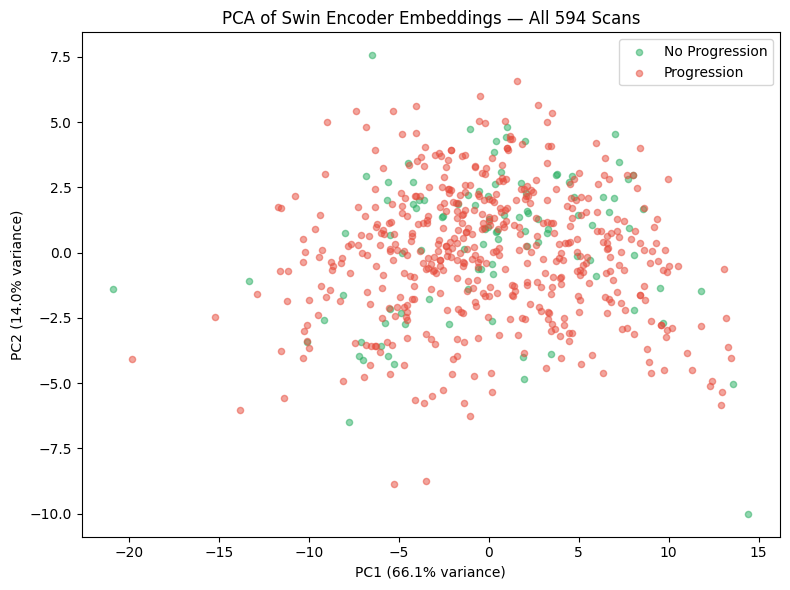

In [20]:
# ── Build label dict ──────────────────────────────────────────────────────────
label_dict = dict(zip(clinical['Patient_ID'], clinical['Progression']))

# ── Load embeddings from Drive ────────────────────────────────────────────────
files_on_drive = list_already_done(output_folder_id)
pt_files = sorted([f for f in files_on_drive if f.endswith('.pt')])

embeddings, labels, pids = [], [], []

for fname in pt_files:
    pid = fname.split('_Timepoint')[0]
    if pid not in label_dict:
        continue

    # Download .pt to /tmp, load, delete
    local_pt = f'/tmp/{fname}'
    file_id_results = service.files().list(
        q=f"'{output_folder_id}' in parents and name='{fname}' and trashed=false",
        fields="files(id)"
    ).execute()
    if not file_id_results['files']:
        continue
    fid = file_id_results['files'][0]['id']
    download_file_to_tmp(fid, fname)

    emb = torch.load(local_pt).squeeze().numpy()
    embeddings.append(emb)
    labels.append(label_dict[pid])
    pids.append(pid)
    os.remove(local_pt)

X = np.array(embeddings)
y = np.array(labels)
print(f'Loaded {len(X)} embeddings, {y.sum():.0f} progression, {(1-y).sum():.0f} no progression')

# ── PCA ───────────────────────────────────────────────────────────────────────
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#27AE60', 'No Progression'), (1, '#E74C3C', 'Progression')]:
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name, alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend()
ax.set_title('PCA of Swin Encoder Embeddings — All 594 Scans')
plt.tight_layout()
# After plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)

file_meta = {'name': 'fig_pca_embeddings.png', 'parents': [root_folder_id]}
media = MediaIoBaseUpload(buf, mimetype='image/png', resumable=True)
uploaded = service.files().create(body=file_meta, media_body=media, fields='id').execute()
print(f"PCA figure uploaded to Drive: {uploaded['id']}")

plt.savefig('fig_pca_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

Trajectory figure uploaded to Drive: 1ffbJkvhidepklDxheDK-UPkDQHYOnG7w


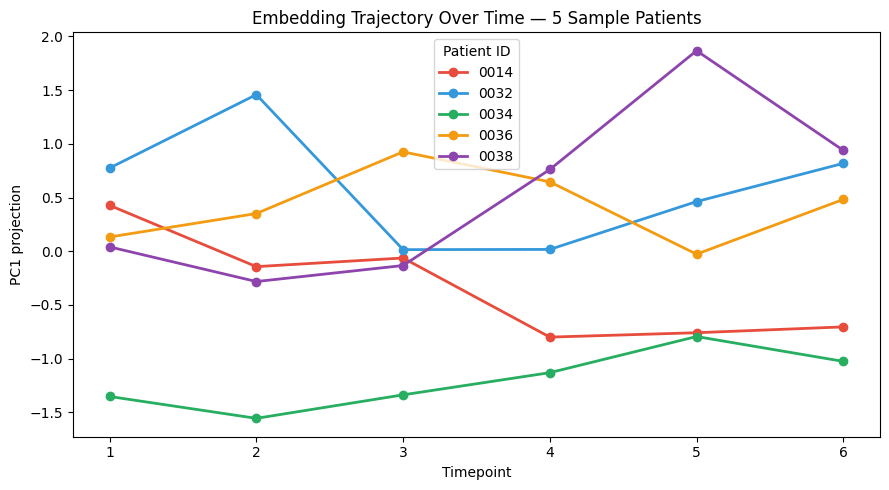

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import defaultdict

# ── Build patient → timepoints map from Drive file list ──────────────────────
files_on_drive = list_already_done(output_folder_id)
pt_files = sorted([f for f in files_on_drive if f.endswith('.pt')])

patient_tps = defaultdict(list)
for fname in pt_files:
    parts = fname.replace('_embedding.pt', '').split('_Timepoint_')
    patient_tps[parts[0]].append(int(parts[1]))

# Pick 5 patients with most timepoints
top_patients = sorted(patient_tps, key=lambda p: -len(patient_tps[p]))[:5]

# ── Download embeddings for those 5 patients and run PCA ─────────────────────
all_embs = []
for pid in top_patients:
    for tp in sorted(patient_tps[pid]):
        fname = f'{pid}_Timepoint_{tp}_embedding.pt'
        file_id_results = service.files().list(
            q=f"'{output_folder_id}' in parents and name='{fname}' and trashed=false",
            fields="files(id)"
        ).execute()
        if not file_id_results['files']:
            continue
        fid = file_id_results['files'][0]['id']
        local_pt = download_file_to_tmp(fid, fname)
        emb = torch.load(local_pt).squeeze().numpy()
        all_embs.append(emb)
        os.remove(local_pt)

pca = PCA(n_components=1)
pca.fit(np.array(all_embs))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C', '#3498DB', '#27AE60', '#F39C12', '#8E44AD']
for i, pid in enumerate(top_patients):
    tps = sorted(patient_tps[pid])
    vals = []
    for tp in tps:
        fname = f'{pid}_Timepoint_{tp}_embedding.pt'
        file_id_results = service.files().list(
            q=f"'{output_folder_id}' in parents and name='{fname}' and trashed=false",
            fields="files(id)"
        ).execute()
        if not file_id_results['files']:
            continue
        fid = file_id_results['files'][0]['id']
        local_pt = download_file_to_tmp(fid, fname)
        emb = torch.load(local_pt).squeeze().numpy()
        vals.append(pca.transform([emb])[0, 0])
        os.remove(local_pt)
    ax.plot(tps, vals, marker='o', color=colors[i], label=pid[-4:], linewidth=2)

ax.set_xlabel('Timepoint')
ax.set_ylabel('PC1 projection')
ax.set_title('Embedding Trajectory Over Time — 5 Sample Patients')
ax.legend(title='Patient ID')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)

file_meta = {'name': 'fig_trajectory.png', 'parents': [root_folder_id]}
media = MediaIoBaseUpload(buf, mimetype='image/png', resumable=True)
uploaded = service.files().create(body=file_meta, media_body=media, fields='id').execute()
print(f"Trajectory figure uploaded to Drive: {uploaded['id']}")

plt.savefig('fig_trajectory.png', dpi=300, bbox_inches='tight')  # local backup
plt.show()

In [23]:
# — Final summary print for presentation evidence
print("=" * 55)
print("SWIN UNETR — UPDATE 3 FIGURE SUMMARY")
print("=" * 55)
print(f"  Embeddings on Drive:     594 files")
print(f"  Patients covered:        203")
print(f"  Embedding shape:         (48,) per scan")
print(f"  Class breakdown:         492 progression / 102 no-progression")
print()
print(f"  PCA variance explained:  PC1={pca.explained_variance_ratio_[0]*100:.1f}%  (1-component fit)")
print()
print("  Figures saved to Drive at 300 DPI:")
print("    fig_coverage.png    — embedding coverage heatmap")
print("    fig_pca_embeddings.png — PCA of all 594 scans")
print("    fig_trajectory.png  — PC1 trajectory, 5 patients")
print("=" * 55)

SWIN UNETR — UPDATE 3 FIGURE SUMMARY
  Embeddings on Drive:     594 files
  Patients covered:        203
  Embedding shape:         (48,) per scan
  Class breakdown:         492 progression / 102 no-progression

  PCA variance explained:  PC1=92.7%  (1-component fit)

  Figures saved to Drive at 300 DPI:
    fig_coverage.png    — embedding coverage heatmap
    fig_pca_embeddings.png — PCA of all 594 scans
    fig_trajectory.png  — PC1 trajectory, 5 patients
